In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Customer_Revenue_Intelligence\data\processed\online_retail_clean.csv",
                 parse_dates=['InvoiceDate'])

print(f"Clean dataset loaded: {len(df):,} rows, {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")

Clean dataset loaded: 779,407 rows, 9 columns
Date range: 2009-12-01 to 2011-12-09
Unique customers: 5,878


In [2]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")
print(f"Why: One day after last transaction — standard RFM practice")
print(f"Last transaction in dataset: {df['InvoiceDate'].max().date()}")

Reference date: 2011-12-10
Why: One day after last transaction — standard RFM practice
Last transaction in dataset: 2011-12-09


In [3]:
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"RFM table created: {len(rfm):,} customers")
print(f"\nSample RFM values:")
print(rfm.head(10).to_string())
print(f"\nRFM Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2).to_string())

RFM table created: 5,878 customers

Sample RFM values:
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   4921.53
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
5        12351      375          1    300.93
6        12352       36         10   2849.84
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61

RFM Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


In [4]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("RFM Scores assigned successfully")
print(f"\nSample with scores:")
print(rfm.head(10).to_string())
print(f"\nRFM Score distribution:")
print(rfm[['R_Score','F_Score','M_Score']].describe().round(2).to_string())

RFM Scores assigned successfully

Sample with scores:
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score  RFM_Total
0        12346      326         12  77556.46        2        5        5       255         12
1        12347        2          8   4921.53        5        4        5       545         14
2        12348       75          5   2019.40        3        4        4       344         11
3        12349       19          4   4428.69        5        3        5       535         13
4        12350      310          1    334.40        2        1        2       212          5
5        12351      375          1    300.93        2        1        2       212          5
6        12352       36         10   2849.84        4        5        4       454         13
7        12353      204          2    406.76        2        2        2       222          6
8        12354      232          1   1079.40        2        1        3       213          6
9        12355  

In [5]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    total = row['RFM_Total']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3 and m >= 4:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Needs Attention'
    elif r == 1 and f <= 2 and m <= 2:
        return 'Lost'
    elif total >= 9:
        return 'Promising'
    elif total >= 6:
        return 'About to Sleep'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Segments assigned successfully")
print(f"\nSegment distribution:")
seg_counts = rfm['Segment'].value_counts()
seg_pct = (rfm['Segment'].value_counts(normalize=True) * 100).round(2)
seg_df = pd.DataFrame({'Customer Count': seg_counts, 'Percentage %': seg_pct})
print(seg_df.to_string())

Segments assigned successfully

Segment distribution:
                    Customer Count  Percentage %
Segment                                         
Champion                      1297         22.07
About to Sleep                 880         14.97
Lost                           776         13.20
Loyal Customer                 603         10.26
Potential Loyalist             535          9.10
Hibernating                    532          9.05
New Customer                   443          7.54
Needs Attention                393          6.69
At Risk                        223          3.79
Promising                      196          3.33


In [6]:
seg_revenue = rfm.groupby('Segment').agg(
    Customer_Count=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Revenue=('Monetary', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean')
).round(2)

seg_revenue['Revenue %'] = (seg_revenue['Total_Revenue'] / seg_revenue['Total_Revenue'].sum() * 100).round(2)
seg_revenue = seg_revenue.sort_values('Total_Revenue', ascending=False)

print("=== REVENUE BY SEGMENT ===")
print(seg_revenue.to_string())
print(f"\nTotal Revenue across all segments: £{seg_revenue['Total_Revenue'].sum():,.2f}")

=== REVENUE BY SEGMENT ===
                    Customer_Count  Total_Revenue  Avg_Revenue  Avg_Recency  Avg_Frequency  Revenue %
Segment                                                                                              
Champion                      1297    11859591.49      9143.86        19.96          17.11      68.26
Loyal Customer                 603     2079308.86      3448.27        88.60           7.39      11.97
At Risk                        223      982122.18      4404.14       342.30           8.98       5.65
About to Sleep                 880      588075.55       668.27       262.32           2.03       3.38
Needs Attention                393      523524.67      1332.12       369.27           3.72       3.01
Potential Loyalist             535      487334.84       910.91        56.23           4.33       2.80
New Customer                   443      392267.02       885.48        28.11           1.46       2.26
Lost                           776      189123.21      

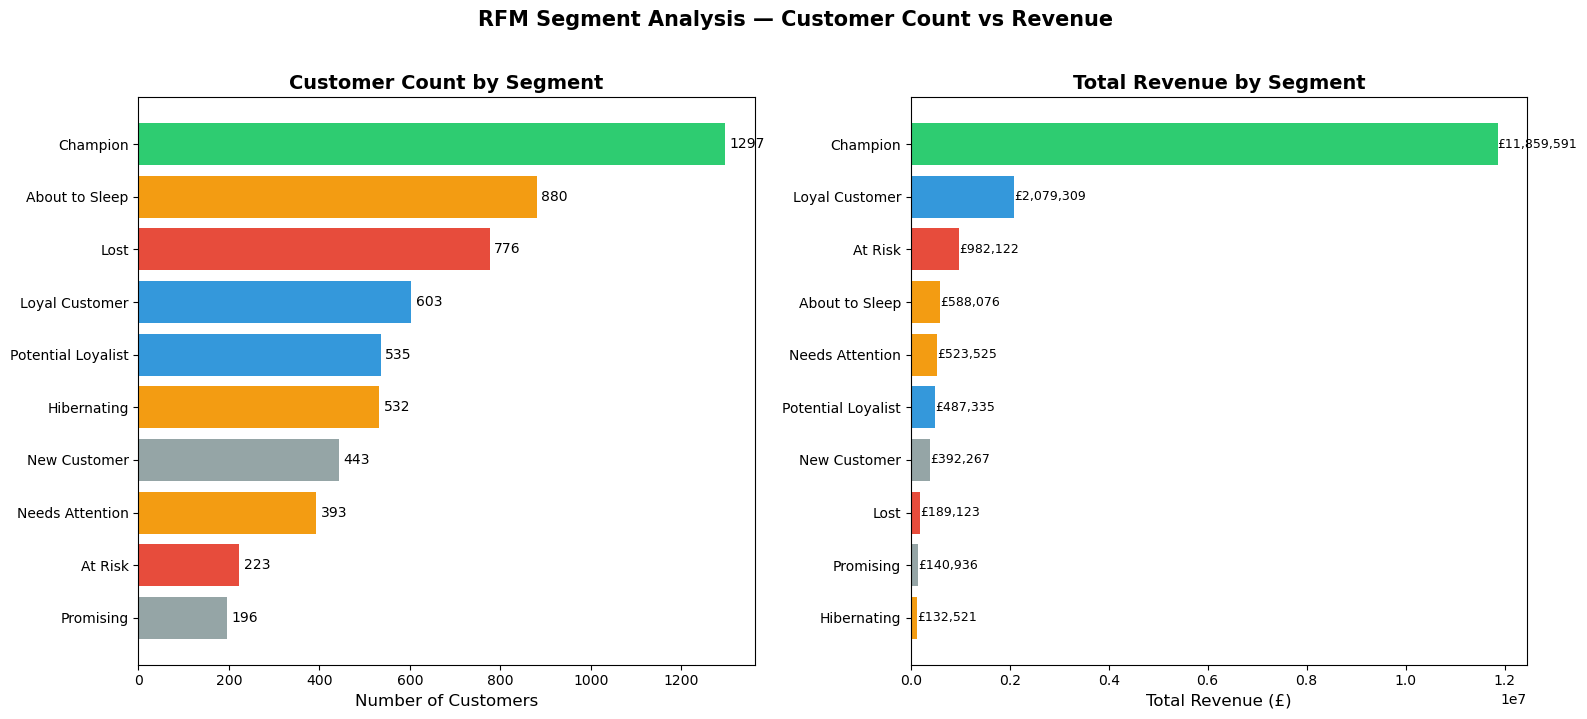

Chart saved to reports/figures/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

seg_order = rfm['Segment'].value_counts().index

colors = ['#2ecc71' if s == 'Champion' else
          '#3498db' if s in ['Loyal Customer', 'Potential Loyalist'] else
          '#e74c3c' if s in ['At Risk', 'Lost'] else
          '#f39c12' if s in ['About to Sleep', 'Hibernating', 'Needs Attention'] else
          '#95a5a6' for s in seg_order]

axes[0].barh(seg_order, rfm['Segment'].value_counts().values, color=colors)
axes[0].set_xlabel('Number of Customers', fontsize=12)
axes[0].set_title('Customer Count by Segment', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(rfm['Segment'].value_counts().values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=10)

rev_order = seg_revenue.index
rev_colors = ['#2ecc71' if s == 'Champion' else
              '#3498db' if s in ['Loyal Customer', 'Potential Loyalist'] else
              '#e74c3c' if s in ['At Risk', 'Lost'] else
              '#f39c12' if s in ['About to Sleep', 'Hibernating', 'Needs Attention'] else
              '#95a5a6' for s in rev_order]

axes[1].barh(rev_order, seg_revenue['Total_Revenue'].values, color=rev_colors)
axes[1].set_xlabel('Total Revenue (£)', fontsize=12)
axes[1].set_title('Total Revenue by Segment', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(seg_revenue['Total_Revenue'].values):
    axes[1].text(v + 1000, i, f'£{v:,.0f}', va='center', fontsize=9)

plt.suptitle('RFM Segment Analysis — Customer Count vs Revenue', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\rfm_segment_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/figures/")

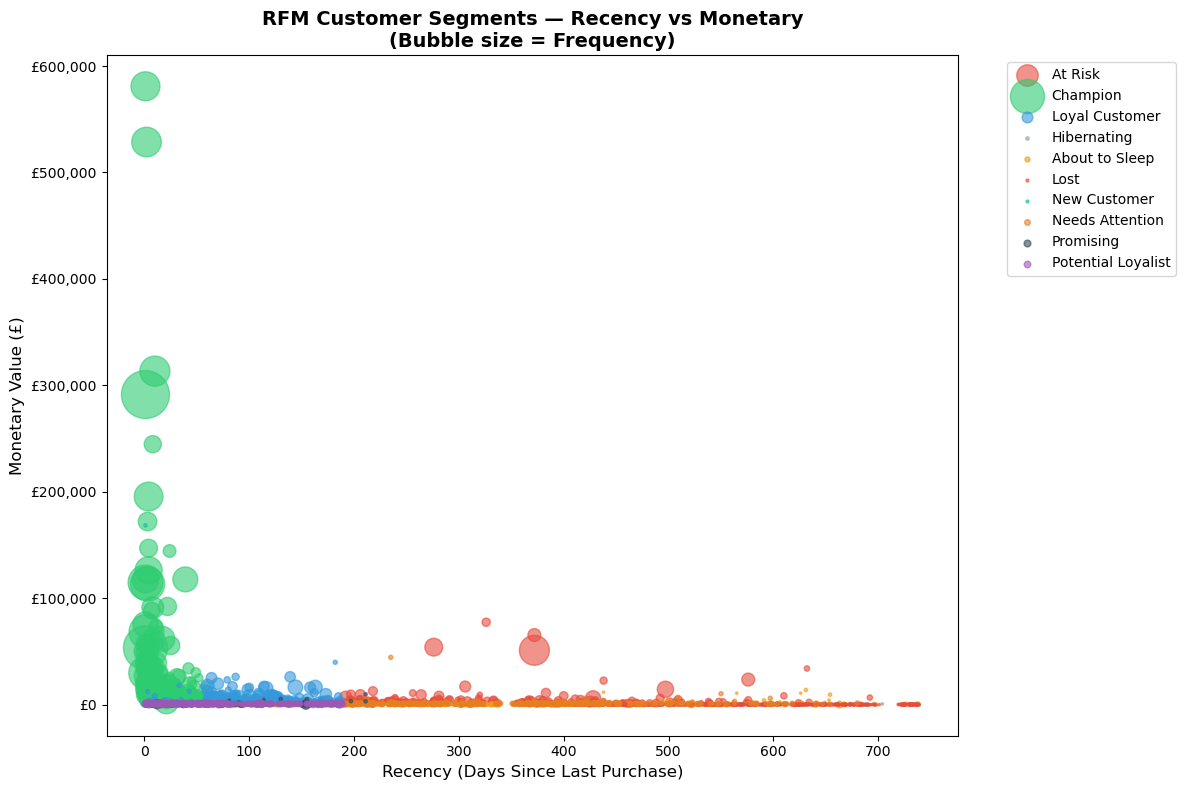

Scatter plot saved to reports/figures/


In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

segment_colors = {
    'Champion': '#2ecc71',
    'Loyal Customer': '#3498db',
    'At Risk': '#e74c3c',
    'About to Sleep': '#f39c12',
    'Needs Attention': '#e67e22',
    'Potential Loyalist': '#9b59b6',
    'New Customer': '#1abc9c',
    'Lost': '#e74c3c',
    'Promising': '#34495e',
    'Hibernating': '#95a5a6'
}

for segment in rfm['Segment'].unique():
    mask = rfm['Segment'] == segment
    ax.scatter(
        rfm[mask]['Recency'],
        rfm[mask]['Monetary'],
        c=segment_colors[segment],
        label=segment,
        alpha=0.6,
        s=rfm[mask]['Frequency'] * 3
    )

ax.set_xlabel('Recency (Days Since Last Purchase)', fontsize=12)
ax.set_ylabel('Monetary Value (£)', fontsize=12)
ax.set_title('RFM Customer Segments — Recency vs Monetary\n(Bubble size = Frequency)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\rfm_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved to reports/figures/")

In [9]:
output_path = r"C:\Customer_Revenue_Intelligence\data\processed\rfm_segments.csv"
rfm.to_csv(output_path, index=False)

print(f"RFM data saved to: {output_path}")
print(f"Rows saved: {len(rfm):,}")
print(f"Columns saved: {list(rfm.columns)}")

RFM data saved to: C:\Customer_Revenue_Intelligence\data\processed\rfm_segments.csv
Rows saved: 5,878
Columns saved: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment']
